<a href="https://colab.research.google.com/github/nozanin-13/ML-Begin/blob/main/%D0%A3%D1%80%D0%BE%D0%BA_7_%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%BE_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Урок 7 — Дерево решений (игра «20 вопросов»)

KNN просто запоминал соседей. Дерево решений **задаёт вопросы** — как в игре «20 вопросов» — и по ответам приходит к решению. А главное: его логику можно **увидеть**!

Запускай ячейки по порядку: ▶ или **Shift+Enter**.

---
### Дерево vs KNN
- **KNN** — «ленивый»: запомнил всех и сравнивает.
- **Дерево** — задаёт вопросы да/нет о признаках и строит понятные правила.

## Шаг 1. Готовим данные (как раньше) и делим на train/test

In [ ]:
import pandas as pd #
from sklearn.model_selection import train_test_split #

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df = df[["Pclass", "Sex", "Age", "Fare", "Survived"]].dropna()
df["Sex"] = (df["Sex"] == "male").astype(int)

X = df[["Pclass", "Sex", "Age", "Fare"]]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("Данные готовы и поделены.")

Данные готовы и поделены.


## Шаг 2. Обучаем дерево 🌳
`max_depth=3` — ограничиваем глубину: дерево задаст не больше 3 вопросов подряд.
Это защищает от «зазубривания».

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)   # дерево УЧИТСЯ — строит правила

print("Дерево обучено!")

Дерево обучено!


## Шаг 3. Проверяем на train и test

In [ ]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))
print("Точность на train:", round(train_acc, 2))
print("Точность на test: ", round(test_acc, 2))

Точность на train: 0.83
Точность на test:  0.74


## Шаг 4. РИСУЕМ дерево 👀
Самое интересное: увидеть, какие вопросы придумало дерево.

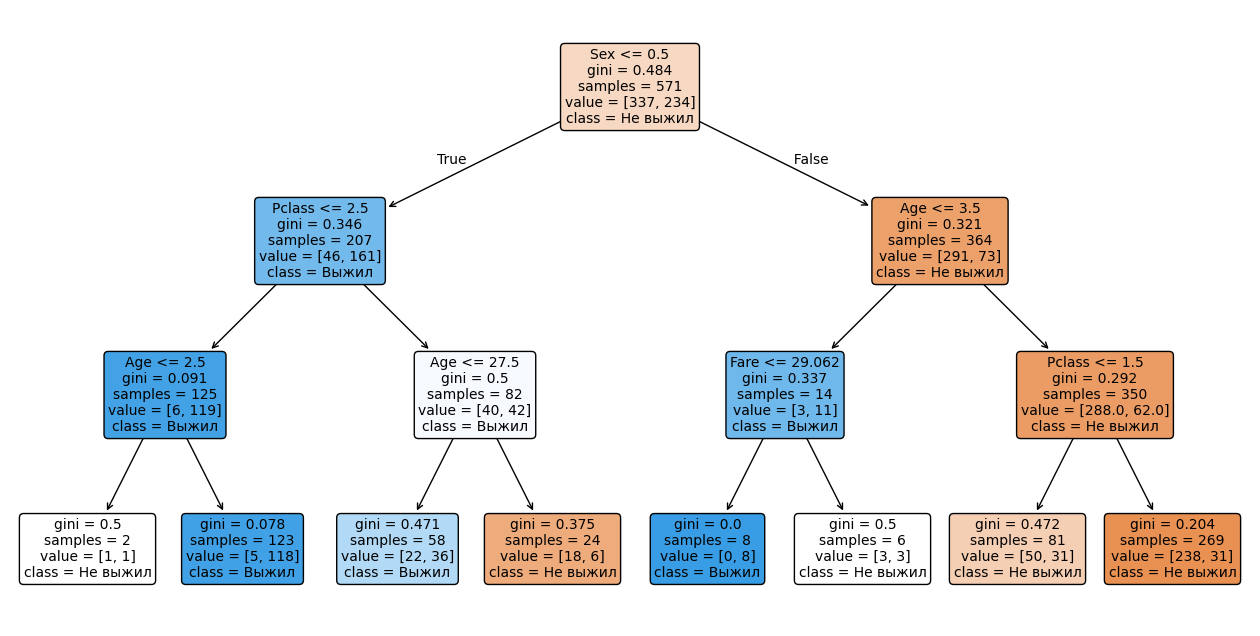

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 8))
plot_tree(model,
          feature_names=["Pclass", "Sex", "Age", "Fare"],
          class_names=["Не выжил", "Выжил"],
          filled=True, rounded=True, fontsize=10)
plt.show()

**Как читать дерево:**
- Каждый прямоугольник — вопрос (например, `Sex <= 0.5` значит «женщина?»).
- Идёшь **влево — если ДА**, вправо — если НЕТ.
- Внизу (листья) — ответ модели.
- Цвет показывает класс: чем ярче, тем увереннее.

## ⚠️ Шаг 5. Что такое переобучение
Уберём ограничение глубины — пусть дерево растёт как хочет.

In [ ]:
# дерево БЕЗ ограничения глубины
big_tree = DecisionTreeClassifier(random_state=42)   # без max_depth
big_tree.fit(X_train, y_train)

print("Огромное дерево:")
print("  train:", round(accuracy_score(y_train, big_tree.predict(X_train)), 2), "← почти идеально!")
print("  test: ", round(accuracy_score(y_test, big_tree.predict(X_test)), 2), "← а тут провал")

Огромное дерево:
  train: 0.99 ← почти идеально!
  test:  0.71 ← а тут провал


**Видишь разрыв?** train ≈ 0.99, а test ≈ 0.71. Дерево **зазубрило** каждого пассажира,
но не научилось общим правилам. Это переобучение.

Лекарство — ограничить глубину (`max_depth`), как в Шаге 2.

## ✍️ Твоё задание
1. Попробуй `max_depth` = 2, 3, 5, 10 — запиши точность train и test для каждого.
2. При какой глубине начинается переобучение (train растёт, test падает)?
3. Посмотри на нарисованное дерево: какой вопрос оно задаёт ПЕРВЫМ? Почему именно этот, как думаешь?

---
**Вывод урока:** дерево решений задаёт вопросы да/нет и строит понятные правила —
их можно увидеть через `plot_tree`. Это его большой плюс перед KNN.

Но без ограничения глубины дерево переобучается (зазубривает). Спасает `max_depth`.

**Домашка:** перебери глубины, найди начало переобучения, прочитай первый вопрос дерева.